<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/FM_teoria_de_se%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se cargarán 9 archivos CSV, uno por uno.

Carga el archivo 1 de 9


Saving Node1-Bogota (3).csv to Node1-Bogota (3) (2).csv
Carga el archivo 2 de 9


Saving Node2-Bogota (4).csv to Node2-Bogota (4).csv
Carga el archivo 3 de 9


Saving Node3-Bogota (3).csv to Node3-Bogota (3).csv
Carga el archivo 4 de 9


Saving Node4-Bogota (3).csv to Node4-Bogota (3).csv
Carga el archivo 5 de 9


Saving Node5-Bogota (3).csv to Node5-Bogota (3).csv
Carga el archivo 6 de 9


Saving Node6-Bogota (3).csv to Node6-Bogota (3).csv
Carga el archivo 7 de 9


Saving Node7-Bogota (4).csv to Node7-Bogota (4).csv
Carga el archivo 8 de 9


Saving Node8-Bogota (4).csv to Node8-Bogota (4).csv
Carga el archivo 9 de 9


Saving Node10-Bogota (3).csv to Node10-Bogota (3).csv

Carga completada correctamente.

Archivos detectados:
- Node1-Bogota (3) (2).csv
- Node1-Bogota (3).csv
- Node1-Bogota (3) (1).csv
- Node2-Bogota (4).csv
- Node3-Bogota (3).csv
- Node4-Bogota (3).csv
- Node5-Bogota (3).csv
- Node6-Bogota (3).csv
- Node7-Bogota (4).csv
- Node8-Bogota (4).csv
- Node10-Bogota (3).csv

Archivos que participarán en el análisis:
- Node1-Bogota (3) (2).csv
- Node1-Bogota (3).csv
- Node1-Bogota (3) (1).csv
- Node2-Bogota (4).csv
- Node3-Bogota (3).csv
- Node4-Bogota (3).csv
- Node5-Bogota (3).csv
- Node6-Bogota (3).csv
- Node7-Bogota (4).csv
- Node8-Bogota (4).csv
- Node10-Bogota (3).csv

Resumen de las series cargadas:
Nodo 1: 1/1 adquisiciones válidas, ubicación = Bogota (3) (2)
Nodo 1: 1/1 adquisiciones válidas, ubicación = Bogota (3)
Nodo 1: 1/1 adquisiciones válidas, ubicación = Bogota (3) (1)
Nodo 2: 1/1 adquisiciones válidas, ubicación = Bogota (4)
Nodo 3: 1/1 adquisiciones válidas, ubicación = Bogo

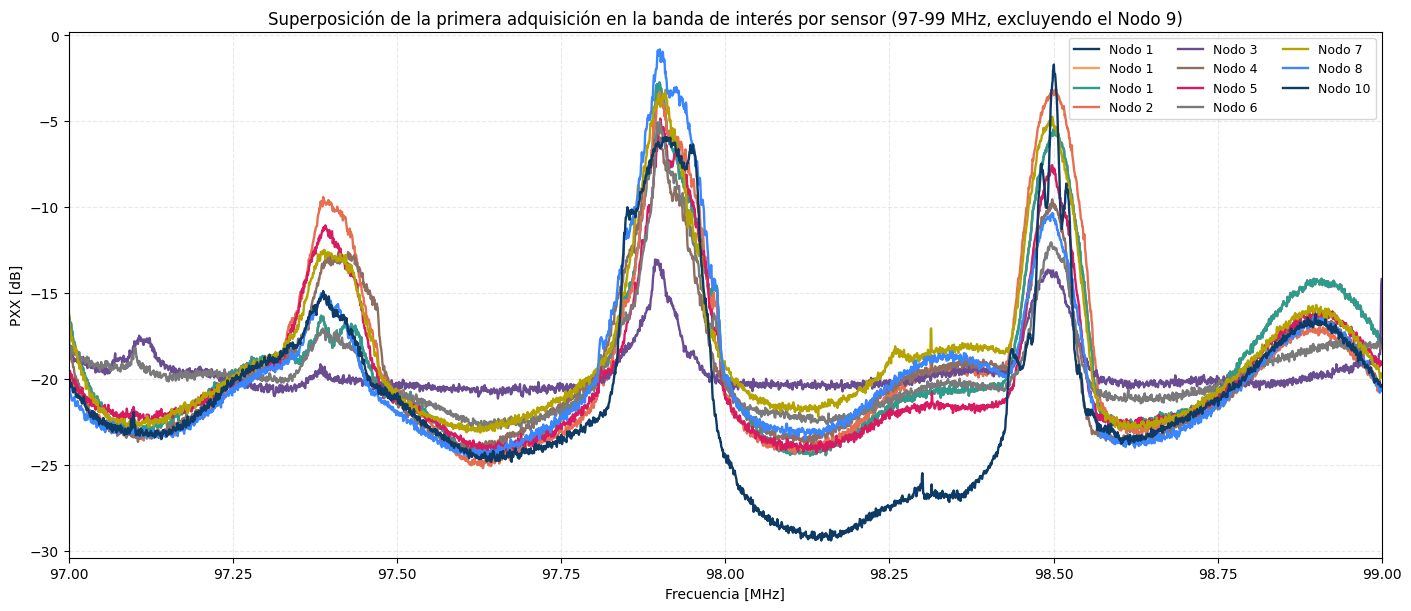

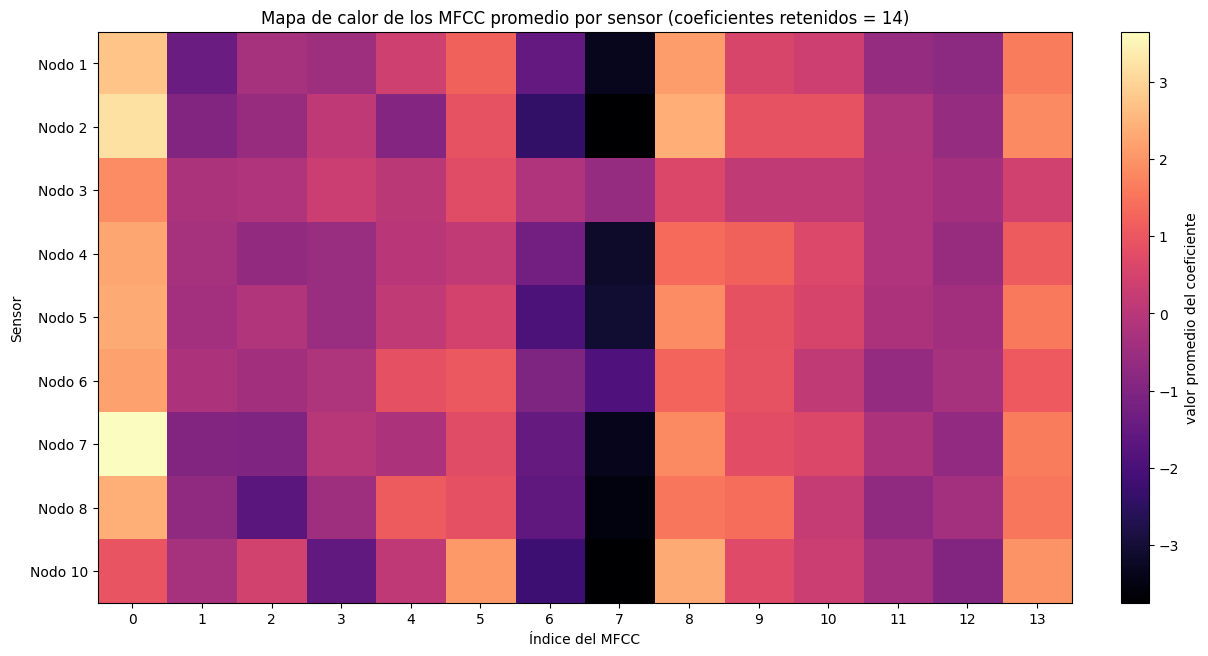

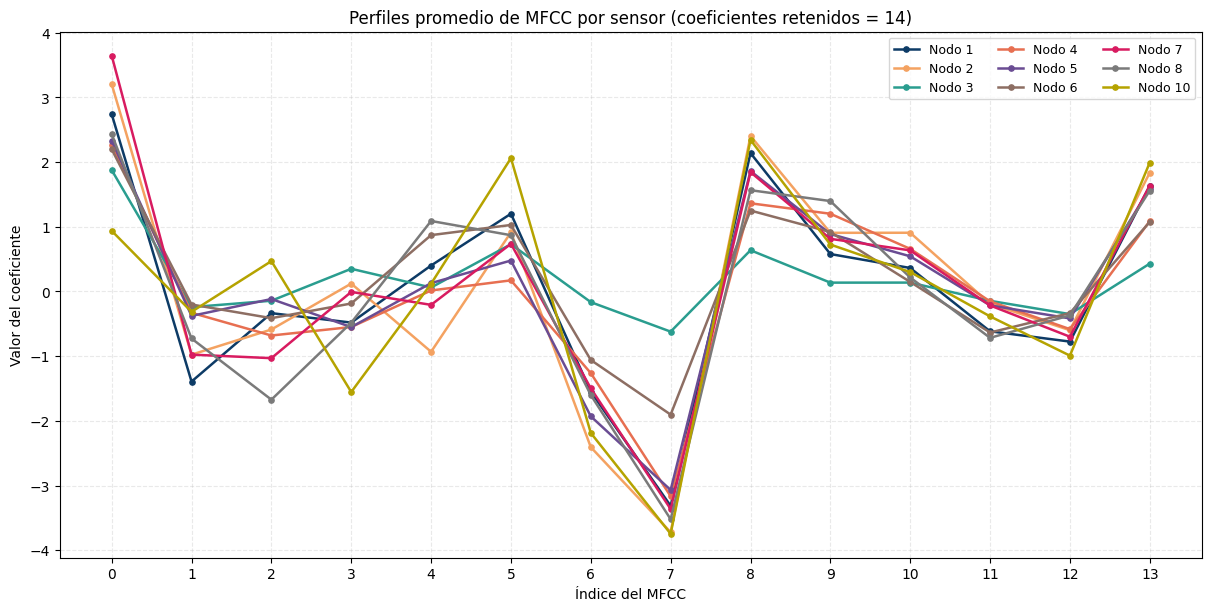

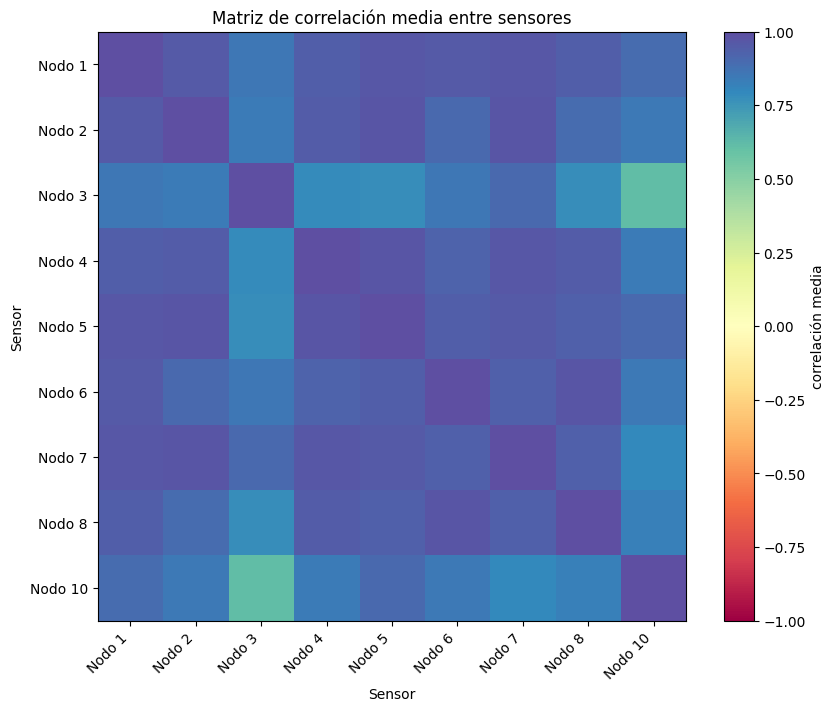

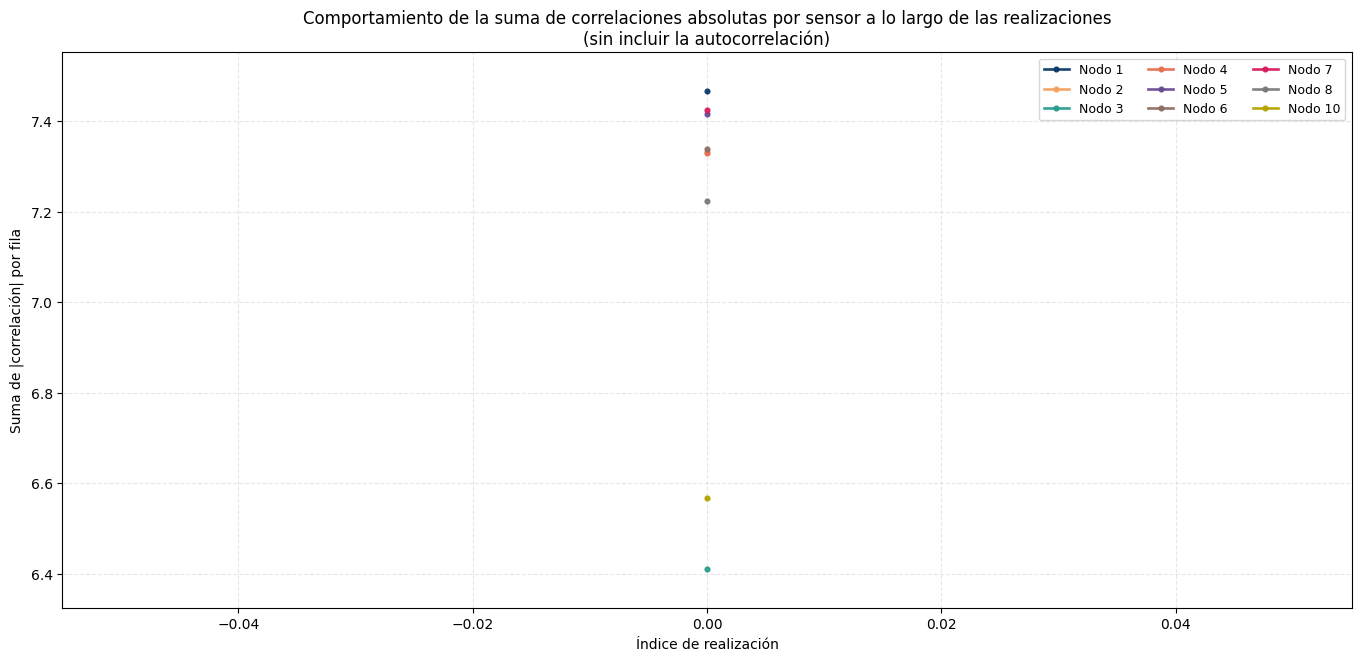

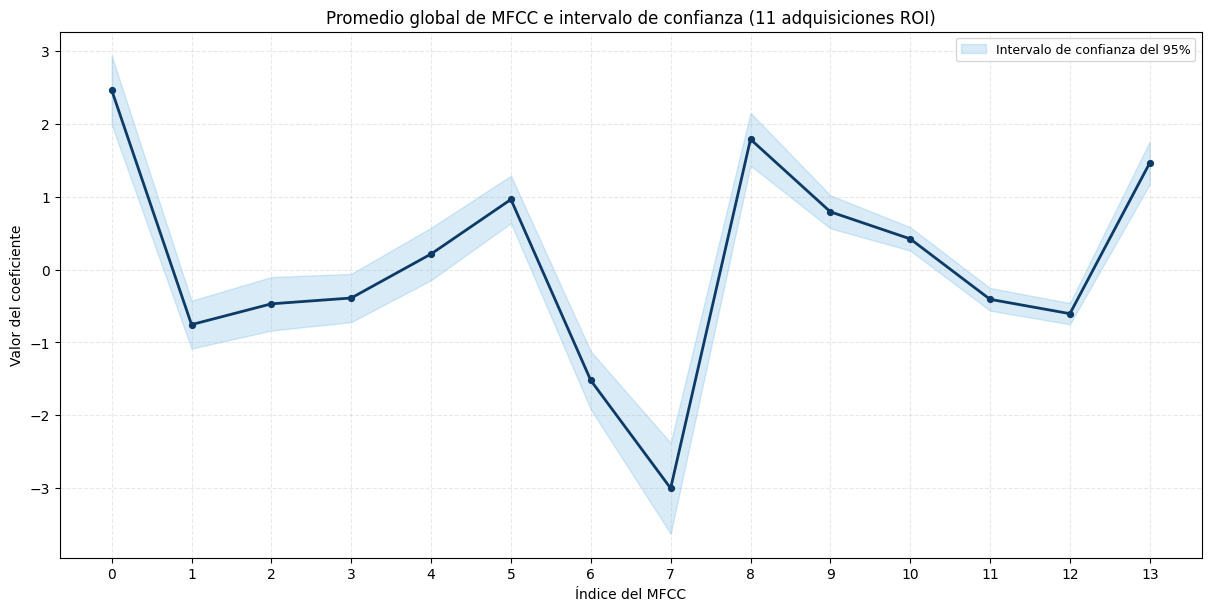

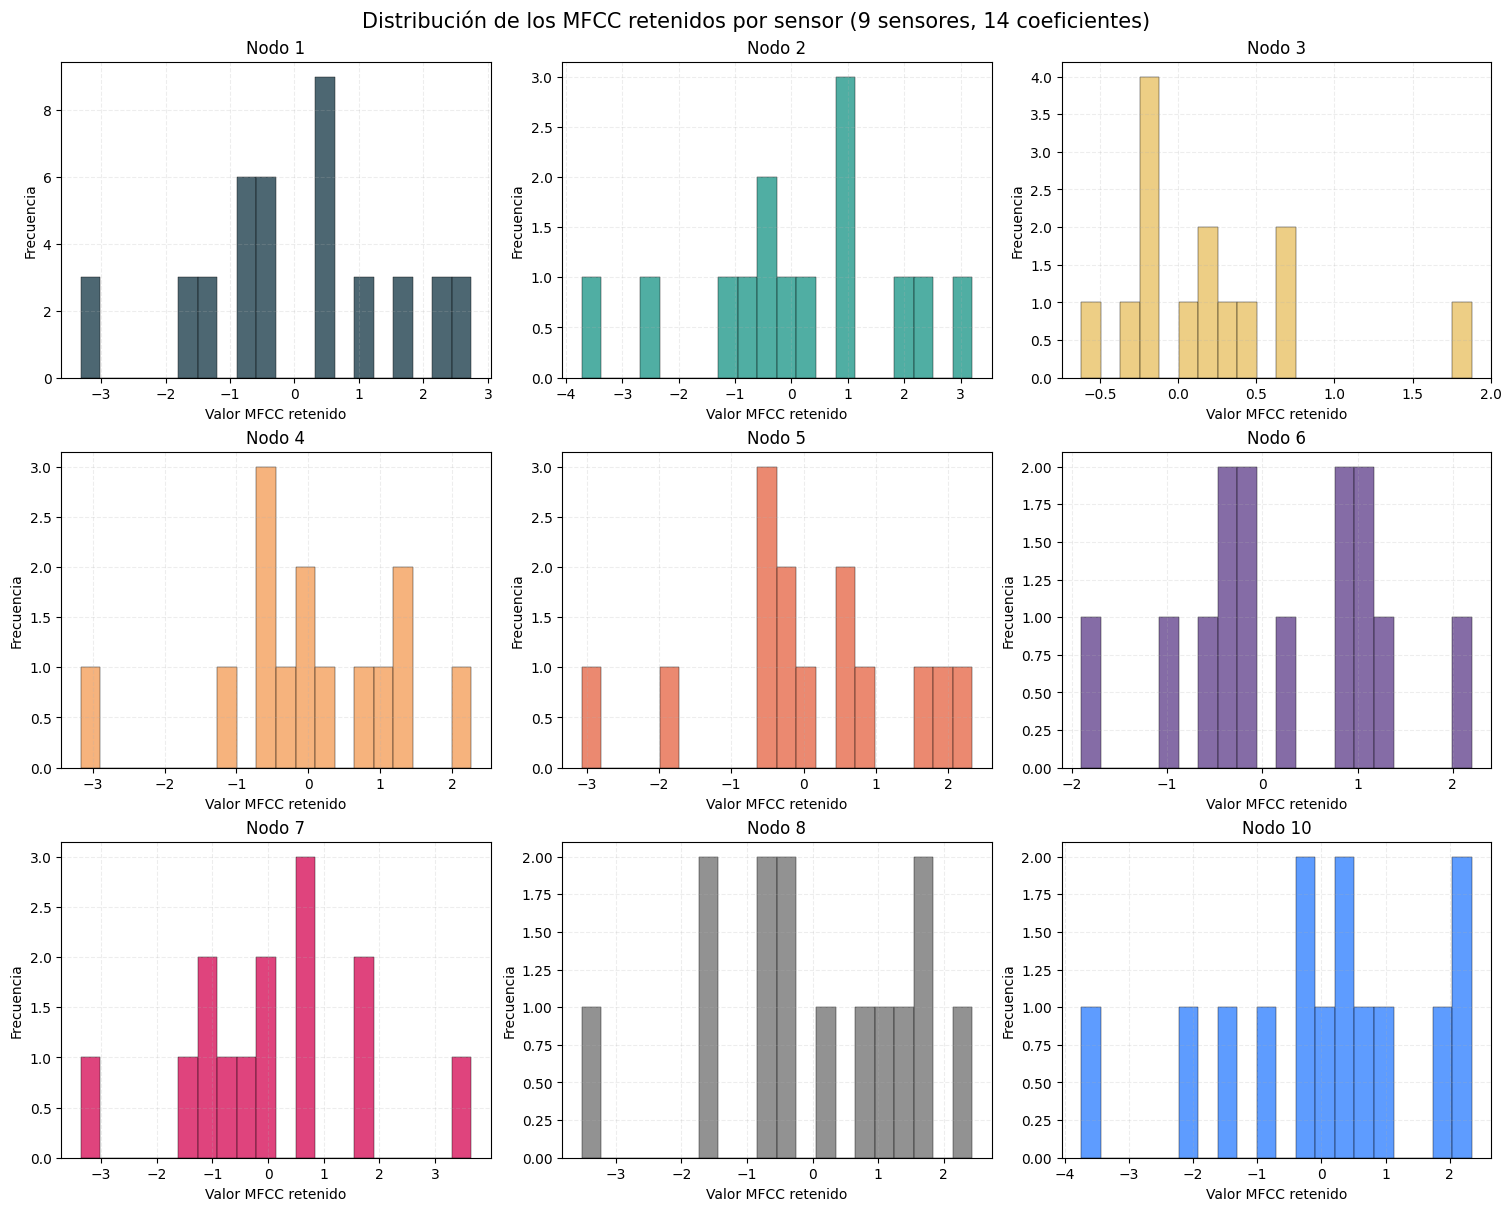

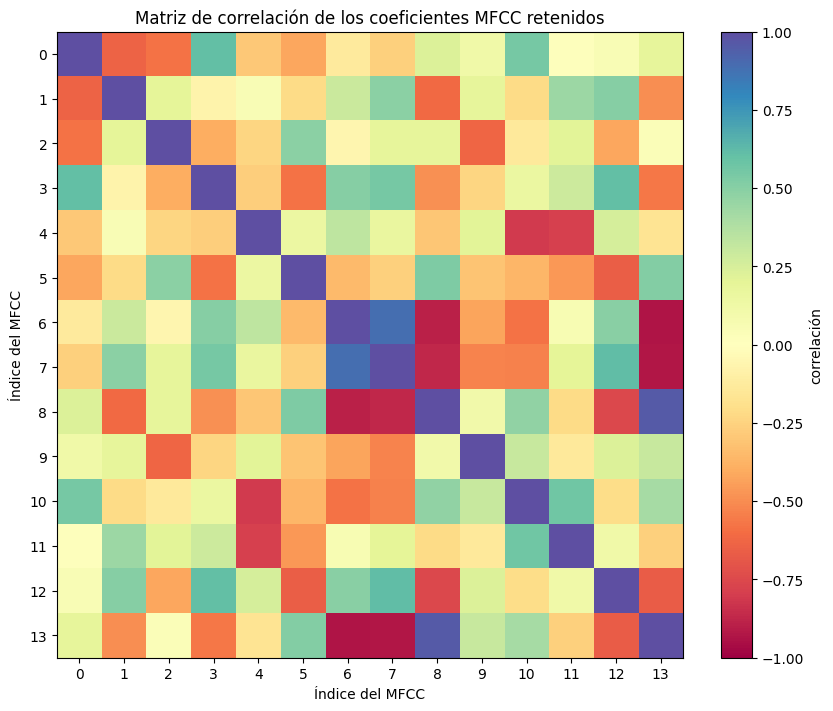

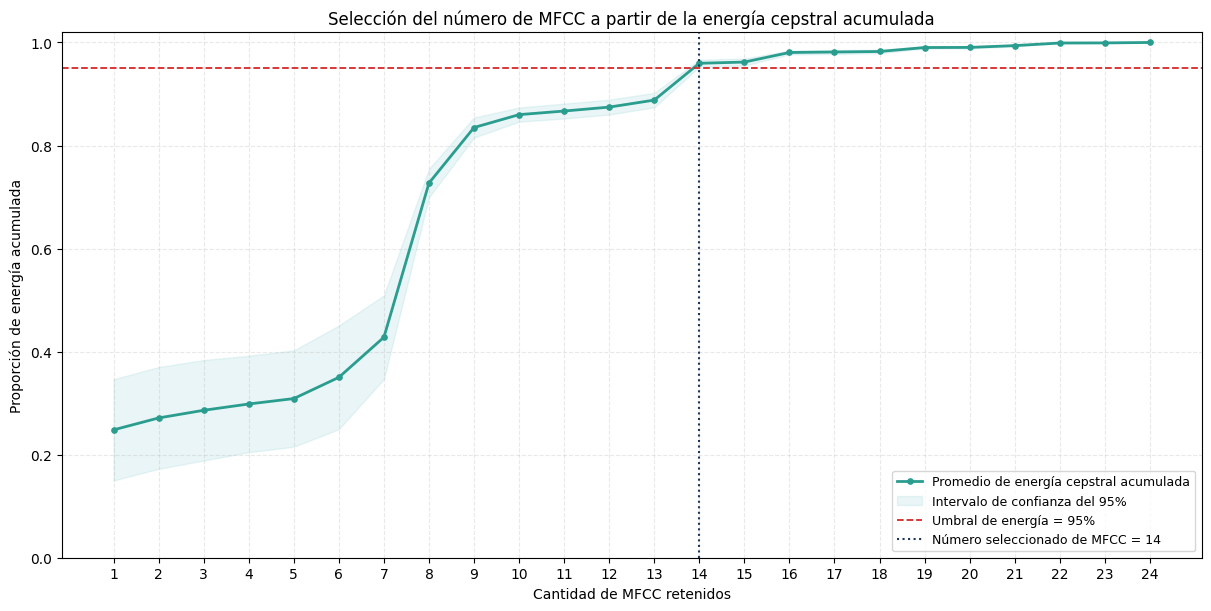

In [17]:
from google.colab import files
from pathlib import Path
import csv
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import dct
from scipy.stats import t

# =========================================================
# PARÁMETROS GENERALES
# =========================================================
csv.field_size_limit(10**9)

ROI_INI_MHZ = 97.0
ROI_FIN_MHZ = 99.0
NODOS_OMITIDOS = {9}
TOTAL_ARCHIVOS_A_CARGAR = 9

NUMERO_BANDAS_MEL = 24
UMBRAL_CAPTURA_ENERGIA = 0.95
NIVEL_CONFIANZA = 0.95
EPS_LOG_MFCC = 1.0e-10

# =========================================================
# PALETA GLOBAL DE COLORES
# =========================================================
PALETA_LINEAS = [
    "#0D3B66",  # azul oscuro
    "#F4A261",  # naranja suave
    "#2A9D8F",  # verde azulado
    "#E76F51",  # coral
    "#6A4C93",  # morado
    "#8D6E63",  # café
    "#D81B60",  # magenta
    "#7A7A7A",  # gris
    "#B5A300",  # oliva
    "#3A86FF",  # azul brillante
]

PALETA_HIST = [
    "#264653", "#2A9D8F", "#E9C46A",
    "#F4A261", "#E76F51", "#6A4C93",
    "#D81B60", "#7A7A7A", "#3A86FF"
]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETA_LINEAS)

# =========================================================
# CARGA DE ARCHIVOS UNO POR UNO
# =========================================================
print(f"Se cargarán {TOTAL_ARCHIVOS_A_CARGAR} archivos CSV, uno por uno.\n")

for k in range(TOTAL_ARCHIVOS_A_CARGAR):
    print(f"Carga el archivo {k+1} de {TOTAL_ARCHIVOS_A_CARGAR}")
    subido = files.upload()
    if len(subido) == 0:
        raise ValueError("No se seleccionó ningún archivo. Ejecuta nuevamente la celda.")

print("\nCarga completada correctamente.")

# =========================================================
# ESTRUCTURAS DE DATOS
# =========================================================
@dataclass(frozen=True)
class SerieRoiSensor:
    indice_sensor: int
    ubicacion: str
    frecuencia_roi_hz: np.ndarray
    trazas_roi_db: np.ndarray
    adquisiciones_totales: int
    adquisiciones_validas: int
    bandas_disponibles_mhz: tuple[tuple[float, float], ...]


@dataclass(frozen=True)
class ObservacionMfcc:
    indice_sensor: int
    ubicacion: str
    indice_adquisicion: int
    energias_log_mel: np.ndarray
    coeficientes_cepstrales_completos: np.ndarray


@dataclass(frozen=True)
class SeleccionEstadisticaMfcc:
    n_mfcc_seleccionado: int
    promedio_energia_acumulada: np.ndarray
    limite_inferior_energia: np.ndarray
    limite_superior_energia: np.ndarray
    nivel_confianza: float
    umbral_energia: float
    numero_observaciones: int


@dataclass(frozen=True)
class EstadisticasGlobalesMfcc:
    promedio_coeficientes: np.ndarray
    intervalo_inferior_coeficientes: np.ndarray
    intervalo_superior_coeficientes: np.ndarray
    matriz_correlacion_coeficientes: np.ndarray


@dataclass(frozen=True)
class ResumenCorrelacionSensores:
    etiquetas_sensores: list[str]
    correlacion_media_sensores: np.ndarray
    indices_realizaciones: np.ndarray
    sumas_absolutas_por_fila: np.ndarray
    sensores_disponibles_por_realizacion: np.ndarray

# =========================================================
# FUNCIONES DE LECTURA Y PREPROCESAMIENTO
# =========================================================
def obtener_indice_sensor(ruta_csv: Path) -> int:
    coincidencia = re.match(r"Node(\d+)-", ruta_csv.stem)
    if coincidencia is None:
        raise ValueError(f"Nombre de archivo inválido: {ruta_csv.name}")
    return int(coincidencia.group(1))


def construir_eje_frecuencias_hz(freq_ini_hz: float, freq_fin_hz: float, n_puntos: int) -> np.ndarray:
    if n_puntos <= 0:
        raise ValueError("n_puntos debe ser mayor que cero.")
    if not np.isfinite(freq_ini_hz) or not np.isfinite(freq_fin_hz):
        raise ValueError("Los límites de frecuencia deben ser finitos.")
    if freq_fin_hz <= freq_ini_hz:
        raise ValueError("freq_fin_hz debe ser mayor que freq_ini_hz.")
    return np.linspace(freq_ini_hz, freq_fin_hz, n_puntos, endpoint=False)


def leer_traza_pxx(texto_pxx: str, nombre_csv: str) -> np.ndarray:
    try:
        vector_pxx = np.fromstring(texto_pxx.strip()[1:-1], sep=",", dtype=np.float32)
    except Exception as exc:
        raise ValueError(f"No fue posible interpretar el campo pxx en {nombre_csv}.") from exc

    if vector_pxx.ndim != 1 or vector_pxx.size == 0:
        raise ValueError(f"El campo pxx de {nombre_csv} no es un vector válido.")
    if not np.isfinite(vector_pxx).all():
        raise ValueError(f"El campo pxx de {nombre_csv} contiene NaN o Inf.")

    return vector_pxx


def cargar_series_roi_desde_csv(ruta_csv: Path, roi_ini_mhz: float, roi_fin_mhz: float) -> SerieRoiSensor:
    if roi_fin_mhz <= roi_ini_mhz:
        raise ValueError("La ROI final debe ser mayor que la ROI inicial.")

    with ruta_csv.open(newline="", encoding="utf-8") as archivo:
        filas = list(csv.DictReader(archivo))

    if not filas:
        raise ValueError(f"El archivo {ruta_csv.name} no contiene datos.")

    roi_ini_hz = roi_ini_mhz * 1e6
    roi_fin_hz = roi_fin_mhz * 1e6

    eje_roi_referencia = None
    coleccion_trazas_roi = []
    bandas_detectadas_hz = set()

    for fila in filas:
        try:
            freq_ini_hz = float(fila["start_freq_hz"])
            freq_fin_hz = float(fila["end_freq_hz"])
        except Exception as exc:
            raise ValueError(f"Metadatos de frecuencia inválidos en {ruta_csv.name}.") from exc

        bandas_detectadas_hz.add((freq_ini_hz, freq_fin_hz))

        pxx_db = leer_traza_pxx(fila["pxx"], ruta_csv.name)
        eje_frecuencia_hz = construir_eje_frecuencias_hz(freq_ini_hz, freq_fin_hz, len(pxx_db))

        mascara_roi = (eje_frecuencia_hz >= roi_ini_hz) & (eje_frecuencia_hz <= roi_fin_hz)
        if not np.any(mascara_roi):
            continue

        eje_roi_actual = eje_frecuencia_hz[mascara_roi]
        traza_roi_actual = pxx_db[mascara_roi]

        if eje_roi_referencia is None:
            eje_roi_referencia = eje_roi_actual
        elif not np.allclose(eje_roi_referencia, eje_roi_actual):
            raise ValueError(f"Inconsistencia en la malla de la ROI dentro de {ruta_csv.name}.")

        coleccion_trazas_roi.append(traza_roi_actual)

    partes_nombre = ruta_csv.stem.split("-", maxsplit=1)
    if len(partes_nombre) != 2:
        raise ValueError(f"No fue posible extraer la ubicación desde {ruta_csv.name}.")

    if eje_roi_referencia is None:
        eje_roi_referencia = np.empty(0, dtype=np.float64)

    matriz_roi = (
        np.vstack(coleccion_trazas_roi)
        if coleccion_trazas_roi
        else np.empty((0, eje_roi_referencia.size), dtype=np.float32)
    )

    bandas_mhz = tuple(sorted((a / 1e6, b / 1e6) for a, b in bandas_detectadas_hz))

    return SerieRoiSensor(
        indice_sensor=obtener_indice_sensor(ruta_csv),
        ubicacion=partes_nombre[1],
        frecuencia_roi_hz=eje_roi_referencia,
        trazas_roi_db=matriz_roi,
        adquisiciones_totales=len(filas),
        adquisiciones_validas=matriz_roi.shape[0],
        bandas_disponibles_mhz=bandas_mhz,
    )

# =========================================================
# FUNCIONES DE ESCALA MEL
# =========================================================
def hz_a_mel(freq_hz: np.ndarray) -> np.ndarray:
    freq_hz = np.asarray(freq_hz, dtype=np.float64)
    return 2595.0 * np.log10(1.0 + freq_hz / 700.0)


def mel_a_hz(valores_mel: np.ndarray) -> np.ndarray:
    valores_mel = np.asarray(valores_mel, dtype=np.float64)
    return 700.0 * (10.0 ** (valores_mel / 2595.0) - 1.0)


def construir_banco_filtros_mel(eje_frecuencia_hz: np.ndarray, n_bandas_mel: int) -> np.ndarray:
    eje_frecuencia_hz = np.asarray(eje_frecuencia_hz, dtype=np.float64)

    if eje_frecuencia_hz.ndim != 1 or eje_frecuencia_hz.size < 3:
        raise ValueError("El eje de frecuencia debe ser 1D y tener al menos 3 puntos.")
    if n_bandas_mel <= 0:
        raise ValueError("El número de bandas mel debe ser positivo.")
    if not np.all(np.isfinite(eje_frecuencia_hz)):
        raise ValueError("El eje de frecuencia contiene valores no finitos.")
    if not np.all(np.diff(eje_frecuencia_hz) > 0):
        raise ValueError("El eje de frecuencia debe ser estrictamente creciente.")

    bordes_mel = np.linspace(
        hz_a_mel(np.array([eje_frecuencia_hz[0]], dtype=np.float64))[0],
        hz_a_mel(np.array([eje_frecuencia_hz[-1]], dtype=np.float64))[0],
        n_bandas_mel + 2,
    )
    bordes_hz = mel_a_hz(bordes_mel)

    banco = np.zeros((n_bandas_mel, eje_frecuencia_hz.size), dtype=np.float32)

    for i in range(n_bandas_mel):
        izquierda = float(bordes_hz[i])
        centro = float(bordes_hz[i + 1])
        derecha = float(bordes_hz[i + 2])

        if not (izquierda < centro < derecha):
            raise ValueError("Los bordes del filtro mel deben ser crecientes.")

        mascara_subida = (eje_frecuencia_hz >= izquierda) & (eje_frecuencia_hz <= centro)
        mascara_bajada = (eje_frecuencia_hz >= centro) & (eje_frecuencia_hz <= derecha)

        banco[i, mascara_subida] = (
            (eje_frecuencia_hz[mascara_subida] - izquierda) / (centro - izquierda)
        ).astype(np.float32, copy=False)

        banco[i, mascara_bajada] = (
            (derecha - eje_frecuencia_hz[mascara_bajada]) / (derecha - centro)
        ).astype(np.float32, copy=False)

    if np.any(banco.sum(axis=1) <= 0):
        raise ValueError("Al menos un filtro mel quedó vacío en la banda de interés.")

    return banco

# =========================================================
# CÁLCULO DE MFCC
# =========================================================
def calcular_log_mel_desde_roi(traza_roi_db: np.ndarray, banco_mel: np.ndarray, eps: float) -> np.ndarray:
    traza_roi_db = np.asarray(traza_roi_db, dtype=np.float64)
    banco_mel = np.asarray(banco_mel, dtype=np.float64)

    if traza_roi_db.ndim != 1:
        raise ValueError("La traza ROI debe ser un vector 1D.")
    if banco_mel.ndim != 2:
        raise ValueError("El banco mel debe ser una matriz 2D.")
    if banco_mel.shape[1] != traza_roi_db.size:
        raise ValueError("Las dimensiones de la traza y el banco mel no coinciden.")
    if eps <= 0:
        raise ValueError("eps debe ser positivo.")
    if not np.all(np.isfinite(traza_roi_db)):
        raise ValueError("La traza ROI contiene valores no válidos.")

    potencia_lineal = 10.0 ** (traza_roi_db / 10.0)
    energia_mel = banco_mel @ potencia_lineal
    return np.log(np.maximum(energia_mel, eps)).astype(np.float32, copy=False)


def construir_observaciones_mfcc(series_por_sensor: list[SerieRoiSensor], n_bandas_mel: int, eps: float) -> list[ObservacionMfcc]:
    observaciones = []

    for serie in series_por_sensor:
        if serie.adquisiciones_validas == 0:
            continue

        banco_mel = construir_banco_filtros_mel(serie.frecuencia_roi_hz, n_bandas_mel)

        for indice_adq, traza_roi_db in enumerate(serie.trazas_roi_db):
            vector_log_mel = calcular_log_mel_desde_roi(traza_roi_db, banco_mel, eps)
            vector_mfcc = dct(vector_log_mel, type=2, norm="ortho").astype(np.float32, copy=False)

            observaciones.append(
                ObservacionMfcc(
                    indice_sensor=serie.indice_sensor,
                    ubicacion=serie.ubicacion,
                    indice_adquisicion=indice_adq,
                    energias_log_mel=vector_log_mel,
                    coeficientes_cepstrales_completos=vector_mfcc,
                )
            )

    if not observaciones:
        raise ValueError("No hay observaciones válidas para el análisis MFCC.")

    return observaciones

# =========================================================
# ESTADÍSTICA
# =========================================================
def calcular_intervalo_confianza(matriz_muestras: np.ndarray, nivel_confianza: float):
    matriz_muestras = np.asarray(matriz_muestras, dtype=np.float64)

    if matriz_muestras.ndim != 2 or matriz_muestras.shape[0] == 0:
        raise ValueError("La matriz de muestras debe ser 2D y tener al menos una fila.")
    if not (0.0 < nivel_confianza < 1.0):
        raise ValueError("El nivel de confianza debe estar entre 0 y 1.")
    if not np.all(np.isfinite(matriz_muestras)):
        raise ValueError("La matriz de muestras contiene NaN o Inf.")

    promedio = matriz_muestras.mean(axis=0)

    if matriz_muestras.shape[0] == 1:
        promedio32 = promedio.astype(np.float32, copy=False)
        return promedio32, promedio32, promedio32

    desviacion = matriz_muestras.std(axis=0, ddof=1)
    error_estandar = desviacion / np.sqrt(float(matriz_muestras.shape[0]))
    t_critico = float(t.ppf(0.5 + nivel_confianza / 2.0, df=matriz_muestras.shape[0] - 1))
    amplitud = t_critico * error_estandar

    return (
        promedio.astype(np.float32, copy=False),
        (promedio - amplitud).astype(np.float32, copy=False),
        (promedio + amplitud).astype(np.float32, copy=False),
    )

# =========================================================
# SELECCIÓN DEL NÚMERO DE MFCC
# =========================================================
def seleccionar_numero_mfcc(observaciones_mfcc: list[ObservacionMfcc], umbral_energia: float, nivel_confianza: float) -> SeleccionEstadisticaMfcc:
    if not observaciones_mfcc:
        raise ValueError("Se requiere al menos una observación MFCC.")
    if not (0.0 < umbral_energia < 1.0):
        raise ValueError("El umbral de energía debe estar entre 0 y 1.")
    if not (0.0 < nivel_confianza < 1.0):
        raise ValueError("El nivel de confianza debe estar entre 0 y 1.")

    matriz_cepstral = np.vstack(
        [obs.coeficientes_cepstrales_completos for obs in observaciones_mfcc]
    ).astype(np.float64, copy=False)

    energia_cepstral = matriz_cepstral ** 2
    energia_total = np.sum(energia_cepstral, axis=1, keepdims=True)

    if np.any(energia_total <= 0):
        raise ValueError("Cada observación debe tener energía cepstral positiva.")

    energia_acumulada_relativa = np.cumsum(energia_cepstral, axis=1) / energia_total
    promedio, inferior, superior = calcular_intervalo_confianza(energia_acumulada_relativa, nivel_confianza)

    inferior = np.clip(inferior, 0.0, 1.0)
    superior = np.clip(superior, 0.0, 1.0)

    candidatos = np.flatnonzero(inferior >= umbral_energia)
    n_mfcc = int(candidatos[0] + 1) if candidatos.size > 0 else int(inferior.size)

    return SeleccionEstadisticaMfcc(
        n_mfcc_seleccionado=n_mfcc,
        promedio_energia_acumulada=promedio,
        limite_inferior_energia=inferior,
        limite_superior_energia=superior,
        nivel_confianza=nivel_confianza,
        umbral_energia=umbral_energia,
        numero_observaciones=len(observaciones_mfcc),
    )


def extraer_matriz_mfcc_retenida(observaciones_mfcc: list[ObservacionMfcc], n_mfcc: int) -> np.ndarray:
    if not observaciones_mfcc:
        raise ValueError("No hay observaciones disponibles.")

    matriz = np.vstack(
        [obs.coeficientes_cepstrales_completos for obs in observaciones_mfcc]
    ).astype(np.float32, copy=False)

    if not (1 <= n_mfcc <= matriz.shape[1]):
        raise ValueError("El número de MFCC retenidos está fuera del rango disponible.")

    return matriz[:, :n_mfcc]


def calcular_estadisticas_globales_mfcc(observaciones_mfcc: list[ObservacionMfcc], n_mfcc: int, nivel_confianza: float) -> EstadisticasGlobalesMfcc:
    matriz_retenida = extraer_matriz_mfcc_retenida(observaciones_mfcc, n_mfcc).astype(np.float64, copy=False)

    promedio, inferior, superior = calcular_intervalo_confianza(matriz_retenida, nivel_confianza)

    if n_mfcc == 1:
        correlacion = np.ones((1, 1), dtype=np.float32)
    else:
        correlacion = np.corrcoef(matriz_retenida, rowvar=False).astype(np.float32, copy=False)
        correlacion = np.nan_to_num(correlacion, nan=0.0)
        np.fill_diagonal(correlacion, 1.0)

    return EstadisticasGlobalesMfcc(
        promedio_coeficientes=promedio,
        intervalo_inferior_coeficientes=inferior,
        intervalo_superior_coeficientes=superior,
        matriz_correlacion_coeficientes=correlacion,
    )

# =========================================================
# PROMEDIOS Y CORRELACIÓN ENTRE SENSORES
# =========================================================
def construir_matriz_promedio_por_sensor(observaciones_mfcc: list[ObservacionMfcc], n_mfcc: int):
    agrupado = {}
    for obs in observaciones_mfcc:
        agrupado.setdefault(obs.indice_sensor, []).append(
            obs.coeficientes_cepstrales_completos[:n_mfcc]
        )

    sensores_ordenados = sorted(agrupado)
    etiquetas = [f"Nodo {sid}" for sid in sensores_ordenados]

    matriz_promedio = np.vstack(
        [np.vstack(agrupado[sid]).mean(axis=0) for sid in sensores_ordenados]
    ).astype(np.float32, copy=False)

    return etiquetas, matriz_promedio


def resumir_correlacion_entre_sensores(observaciones_mfcc: list[ObservacionMfcc], n_mfcc: int) -> ResumenCorrelacionSensores:
    if n_mfcc <= 0:
        raise ValueError("n_mfcc debe ser positivo.")
    if not observaciones_mfcc:
        raise ValueError("Se requiere al menos una observación.")

    sensores_ordenados = sorted({obs.indice_sensor for obs in observaciones_mfcc})
    etiquetas = [f"Nodo {sid}" for sid in sensores_ordenados]
    posicion_sensor = {sid: pos for pos, sid in enumerate(sensores_ordenados)}

    datos_por_realizacion = {}
    for obs in observaciones_mfcc:
        datos_por_realizacion.setdefault(obs.indice_adquisicion, {})[obs.indice_sensor] = (
            obs.coeficientes_cepstrales_completos[:n_mfcc]
        )

    realizaciones = np.asarray(sorted(datos_por_realizacion), dtype=np.int32)
    n_sensores = len(sensores_ordenados)
    n_realizaciones = realizaciones.size

    acumulado_correlacion = np.zeros((n_sensores, n_sensores), dtype=np.float64)
    conteo_correlacion = np.zeros((n_sensores, n_sensores), dtype=np.int32)
    suma_absoluta_filas = np.full((n_sensores, n_realizaciones), np.nan, dtype=np.float32)
    cantidad_sensores = np.empty(n_realizaciones, dtype=np.int32)

    for pos_real, ind_real in enumerate(realizaciones):
        coeficientes_real = datos_por_realizacion[int(ind_real)]
        sensores_disponibles = sorted(coeficientes_real)
        cantidad_sensores[pos_real] = len(sensores_disponibles)

        matriz_real = np.vstack(
            [coeficientes_real[sid] for sid in sensores_disponibles]
        ).astype(np.float64, copy=False)

        if len(sensores_disponibles) == 1:
            correlacion_real = np.ones((1, 1), dtype=np.float64)
        else:
            correlacion_real = np.corrcoef(matriz_real, rowvar=True)
            correlacion_real = np.nan_to_num(correlacion_real, nan=0.0)
            np.fill_diagonal(correlacion_real, 1.0)

        posiciones = np.asarray([posicion_sensor[sid] for sid in sensores_disponibles], dtype=np.int32)
        acumulado_correlacion[np.ix_(posiciones, posiciones)] += correlacion_real
        conteo_correlacion[np.ix_(posiciones, posiciones)] += 1

        suma_fila = np.abs(correlacion_real).sum(axis=1) - 1.0
        suma_absoluta_filas[posiciones, pos_real] = suma_fila.astype(np.float32, copy=False)

    correlacion_media = np.divide(
        acumulado_correlacion,
        conteo_correlacion,
        out=np.zeros_like(acumulado_correlacion),
        where=conteo_correlacion > 0,
    ).astype(np.float32, copy=False)

    correlacion_media = np.nan_to_num(correlacion_media, nan=0.0)
    np.fill_diagonal(correlacion_media, 1.0)

    return ResumenCorrelacionSensores(
        etiquetas_sensores=etiquetas,
        correlacion_media_sensores=correlacion_media,
        indices_realizaciones=realizaciones,
        sumas_absolutas_por_fila=suma_absoluta_filas,
        sensores_disponibles_por_realizacion=cantidad_sensores,
    )

# =========================================================
# FUNCIONES DE VISUALIZACIÓN
# =========================================================
def graficar_superposicion_primera_roi(series_por_sensor: list[SerieRoiSensor], roi_ini_mhz: float, roi_fin_mhz: float) -> None:
    fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
    trazas = []

    for serie in series_por_sensor:
        if serie.adquisiciones_validas == 0:
            continue

        primera_traza = serie.trazas_roi_db[0]
        trazas.append(primera_traza)

        ax.plot(
            serie.frecuencia_roi_hz / 1e6,
            primera_traza,
            linewidth=1.7,
            label=f"Nodo {serie.indice_sensor}",
        )

    if not trazas:
        raise ValueError("No hay adquisiciones ROI válidas para graficar.")

    ax.set_title(
        f"Superposición de la primera adquisición en la banda de interés por sensor "
        f"({roi_ini_mhz:.0f}-{roi_fin_mhz:.0f} MHz, excluyendo el Nodo 9)"
    )
    ax.set_xlabel("Frecuencia [MHz]")
    ax.set_ylabel("PXX [dB]")
    ax.set_xlim(roi_ini_mhz, roi_fin_mhz)
    ax.set_ylim(
        min(float(tr.min()) for tr in trazas) - 1.0,
        max(float(tr.max()) for tr in trazas) + 1.0,
    )
    ax.grid(True, alpha=0.28, linestyle="--")
    ax.legend(ncols=3, fontsize=9, frameon=True)
    plt.show()


def graficar_mapa_calor_mfcc(etiquetas_sensores: list[str], matriz_promedio: np.ndarray, n_mfcc: int) -> None:
    fig, ax = plt.subplots(
        figsize=(12, max(4.5, 0.55 * len(etiquetas_sensores) + 1.5)),
        constrained_layout=True,
    )
    im = ax.imshow(matriz_promedio, aspect="auto", origin="upper", cmap="magma")
    ax.set_title(f"Mapa de calor de los MFCC promedio por sensor (coeficientes retenidos = {n_mfcc})")
    ax.set_xlabel("Índice del MFCC")
    ax.set_ylabel("Sensor")
    ax.set_yticks(np.arange(len(etiquetas_sensores)), labels=etiquetas_sensores)
    ax.set_xticks(np.arange(n_mfcc))
    fig.colorbar(im, ax=ax, label="valor promedio del coeficiente")
    plt.show()


def graficar_perfiles_promedio_mfcc(etiquetas_sensores: list[str], matriz_promedio: np.ndarray, n_mfcc: int) -> None:
    indices = np.arange(n_mfcc)
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

    for etiqueta, fila in zip(etiquetas_sensores, matriz_promedio):
        ax.plot(
            indices,
            fila,
            linewidth=1.8,
            marker="o",
            markersize=3.8,
            label=etiqueta,
        )

    ax.set_title(f"Perfiles promedio de MFCC por sensor (coeficientes retenidos = {n_mfcc})")
    ax.set_xlabel("Índice del MFCC")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_xticks(indices)
    ax.grid(True, alpha=0.28, linestyle="--")
    ax.legend(ncols=3, fontsize=9, frameon=True)
    plt.show()


def graficar_matriz_correlacion_sensores(resumen: ResumenCorrelacionSensores) -> None:
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
    im = ax.imshow(
        resumen.correlacion_media_sensores,
        vmin=-1.0,
        vmax=1.0,
        cmap="Spectral",
        origin="upper",
    )

    posiciones = np.arange(len(resumen.etiquetas_sensores))
    ax.set_title("Matriz de correlación media entre sensores")
    ax.set_xlabel("Sensor")
    ax.set_ylabel("Sensor")
    ax.set_xticks(posiciones, labels=resumen.etiquetas_sensores)
    ax.set_yticks(posiciones, labels=resumen.etiquetas_sensores)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.colorbar(im, ax=ax, label="correlación media")
    plt.show()


def graficar_evolucion_correlacion_por_realizacion(resumen: ResumenCorrelacionSensores) -> None:
    fig, ax = plt.subplots(figsize=(13.5, 6.5), constrained_layout=True)

    valores_validos = resumen.sumas_absolutas_por_fila[np.isfinite(resumen.sumas_absolutas_por_fila)]
    if valores_validos.size == 0:
        raise ValueError("No hay valores válidos para graficar la evolución de correlaciones.")

    y_min = float(np.min(valores_validos))
    y_max = float(np.max(valores_validos))
    margen = 0.08 * (y_max - y_min) if y_max > y_min else 0.2

    for etiqueta, fila in zip(resumen.etiquetas_sensores, resumen.sumas_absolutas_por_fila):
        ax.plot(
            resumen.indices_realizaciones,
            fila,
            linewidth=1.9,
            marker="o",
            markersize=3.4,
            alpha=0.95,
            label=etiqueta,
        )

    ax.set_title(
        "Comportamiento de la suma de correlaciones absolutas por sensor a lo largo de las realizaciones\n"
        "(sin incluir la autocorrelación)"
    )
    ax.set_xlabel("Índice de realización")
    ax.set_ylabel("Suma de |correlación| por fila")
    ax.set_ylim(y_min - margen, y_max + margen)
    ax.grid(True, alpha=0.30, linestyle="--")
    ax.legend(ncols=3, fontsize=9, frameon=True, loc="upper right")
    plt.show()


def graficar_estadisticas_globales_mfcc(estadisticas: EstadisticasGlobalesMfcc, seleccion: SeleccionEstadisticaMfcc) -> None:
    indices = np.arange(seleccion.n_mfcc_seleccionado)

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    ax.plot(
        indices,
        estadisticas.promedio_coeficientes,
        color="#0D3B66",
        linewidth=2.0,
        marker="o",
        markersize=4.2,
    )
    ax.fill_between(
        indices,
        estadisticas.intervalo_inferior_coeficientes,
        estadisticas.intervalo_superior_coeficientes,
        color="#4EA8DE",
        alpha=0.22,
        label=f"Intervalo de confianza del {int(seleccion.nivel_confianza * 100)}%",
    )
    ax.set_title(f"Promedio global de MFCC e intervalo de confianza ({seleccion.numero_observaciones} adquisiciones ROI)")
    ax.set_xlabel("Índice del MFCC")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_xticks(indices)
    ax.grid(True, alpha=0.28, linestyle="--")
    ax.legend(fontsize=9, frameon=True)
    plt.show()


def graficar_histogramas_mfcc(observaciones_mfcc: list[ObservacionMfcc], n_mfcc: int) -> None:
    agrupado = {}
    for obs in observaciones_mfcc:
        agrupado.setdefault(obs.indice_sensor, []).append(
            obs.coeficientes_cepstrales_completos[:n_mfcc]
        )

    sensores_ordenados = sorted(agrupado)
    n_sensores = len(sensores_ordenados)
    n_columnas = 3
    n_filas = int(np.ceil(n_sensores / n_columnas))

    fig, axes = plt.subplots(
        n_filas,
        n_columnas,
        figsize=(15, max(8.0, 4.0 * n_filas)),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for j, (ax, sensor_id) in enumerate(zip(axes, sensores_ordenados)):
        matriz_sensor = np.vstack(agrupado[sensor_id]).astype(np.float32, copy=False)
        valores = matriz_sensor.ravel()

        bins_locales = min(45, max(20, int(np.sqrt(len(valores)) * 3)))

        ax.hist(
            valores,
            bins=bins_locales,
            color=PALETA_HIST[j % len(PALETA_HIST)],
            alpha=0.82,
            edgecolor="black",
            linewidth=0.35,
        )
        ax.set_title(f"Nodo {sensor_id}")
        ax.set_xlabel("Valor MFCC retenido")
        ax.set_ylabel("Frecuencia")
        ax.grid(True, alpha=0.22, linestyle="--")

    for ax in axes[n_sensores:]:
        ax.remove()

    fig.suptitle(
        f"Distribución de los MFCC retenidos por sensor ({n_sensores} sensores, {n_mfcc} coeficientes)",
        fontsize=15,
    )
    plt.show()


def graficar_matriz_correlacion_mfcc(estadisticas: EstadisticasGlobalesMfcc, n_mfcc: int) -> None:
    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
    im = ax.imshow(
        estadisticas.matriz_correlacion_coeficientes,
        vmin=-1.0,
        vmax=1.0,
        cmap="Spectral",
        origin="upper",
    )
    indices = np.arange(n_mfcc)
    ax.set_title("Matriz de correlación de los coeficientes MFCC retenidos")
    ax.set_xlabel("Índice del MFCC")
    ax.set_ylabel("Índice del MFCC")
    ax.set_xticks(indices)
    ax.set_yticks(indices)
    fig.colorbar(im, ax=ax, label="correlación")
    plt.show()


def graficar_suficiencia_energia_mfcc(seleccion: SeleccionEstadisticaMfcc) -> None:
    conteos = np.arange(1, seleccion.promedio_energia_acumulada.size + 1)

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    ax.plot(
        conteos,
        seleccion.promedio_energia_acumulada,
        color="#2A9D8F",
        linewidth=2.0,
        marker="o",
        markersize=3.8,
        label="Promedio de energía cepstral acumulada",
    )
    ax.fill_between(
        conteos,
        seleccion.limite_inferior_energia,
        seleccion.limite_superior_energia,
        color="#A8DADC",
        alpha=0.25,
        label=f"Intervalo de confianza del {int(seleccion.nivel_confianza * 100)}%",
    )
    ax.axhline(
        seleccion.umbral_energia,
        color="#D62828",
        linestyle="--",
        linewidth=1.3,
        label=f"Umbral de energía = {seleccion.umbral_energia:.0%}",
    )
    ax.axvline(
        seleccion.n_mfcc_seleccionado,
        color="#1D3557",
        linestyle=":",
        linewidth=1.5,
        label=f"Número seleccionado de MFCC = {seleccion.n_mfcc_seleccionado}",
    )
    ax.set_title("Selección del número de MFCC a partir de la energía cepstral acumulada")
    ax.set_xlabel("Cantidad de MFCC retenidos")
    ax.set_ylabel("Proporción de energía acumulada")
    ax.set_xticks(conteos)
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.28, linestyle="--")
    ax.legend(fontsize=9, frameon=True)
    plt.show()

# =========================================================
# BLOQUE PRINCIPAL
# =========================================================
carpeta_datos = Path("/content")
rutas_csv = sorted(carpeta_datos.glob("Node*.csv"), key=obtener_indice_sensor)

if len(rutas_csv) == 0:
    raise ValueError("No se encontraron archivos Node*.csv en /content.")

print("\nArchivos detectados:")
for ruta in rutas_csv:
    print("-", ruta.name)

rutas_utiles = [
    ruta for ruta in rutas_csv
    if obtener_indice_sensor(ruta) not in NODOS_OMITIDOS
]

if not rutas_utiles:
    raise ValueError("No hay archivos útiles después de aplicar el filtro de nodos omitidos.")

print("\nArchivos que participarán en el análisis:")
for ruta in rutas_utiles:
    print("-", ruta.name)

series_roi = [
    cargar_series_roi_desde_csv(
        ruta_csv=ruta,
        roi_ini_mhz=ROI_INI_MHZ,
        roi_fin_mhz=ROI_FIN_MHZ,
    )
    for ruta in rutas_utiles
]

print("\nResumen de las series cargadas:")
for serie in series_roi:
    print(
        f"Nodo {serie.indice_sensor}: "
        f"{serie.adquisiciones_validas}/{serie.adquisiciones_totales} adquisiciones válidas, "
        f"ubicación = {serie.ubicacion}"
    )

observaciones_mfcc = construir_observaciones_mfcc(
    series_por_sensor=series_roi,
    n_bandas_mel=NUMERO_BANDAS_MEL,
    eps=EPS_LOG_MFCC,
)

seleccion_mfcc = seleccionar_numero_mfcc(
    observaciones_mfcc=observaciones_mfcc,
    umbral_energia=UMBRAL_CAPTURA_ENERGIA,
    nivel_confianza=NIVEL_CONFIANZA,
)

estadisticas_mfcc = calcular_estadisticas_globales_mfcc(
    observaciones_mfcc=observaciones_mfcc,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
    nivel_confianza=NIVEL_CONFIANZA,
)

etiquetas_sensores, matriz_promedio_sensores = construir_matriz_promedio_por_sensor(
    observaciones_mfcc=observaciones_mfcc,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

resumen_correlacion = resumir_correlacion_entre_sensores(
    observaciones_mfcc=observaciones_mfcc,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

print(f"\nNúmero de MFCC seleccionados: {seleccion_mfcc.n_mfcc_seleccionado}")

# =========================================================
# VISUALIZACIÓN FINAL
# =========================================================
graficar_superposicion_primera_roi(
    series_por_sensor=series_roi,
    roi_ini_mhz=ROI_INI_MHZ,
    roi_fin_mhz=ROI_FIN_MHZ,
)

graficar_mapa_calor_mfcc(
    etiquetas_sensores=etiquetas_sensores,
    matriz_promedio=matriz_promedio_sensores,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

graficar_perfiles_promedio_mfcc(
    etiquetas_sensores=etiquetas_sensores,
    matriz_promedio=matriz_promedio_sensores,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

graficar_matriz_correlacion_sensores(resumen_correlacion)

graficar_evolucion_correlacion_por_realizacion(resumen_correlacion)

graficar_estadisticas_globales_mfcc(
    estadisticas=estadisticas_mfcc,
    seleccion=seleccion_mfcc,
)

graficar_histogramas_mfcc(
    observaciones_mfcc=observaciones_mfcc,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

graficar_matriz_correlacion_mfcc(
    estadisticas=estadisticas_mfcc,
    n_mfcc=seleccion_mfcc.n_mfcc_seleccionado,
)

graficar_suficiencia_energia_mfcc(seleccion_mfcc)